In [22]:
# In this notebook, I am going to build a neural network from scratch using only NumPy 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
np.random.seed(42)

#### Creating generator DS function

In [45]:
# In this cell, I am gonna create function to generate DS with different distributions.
# Uniform, normal, and wide. 
# To make the ds more realistic, I will add some noise
# 2 input features, and 1 output.

def generate_data(size=100, distribution="uniform", target='linear',seed=42):
    np.random.seed(seed)
# Creating values for x between -1 and 1 for uniform distribution.
    if distribution== "uniform":
        X = np.random.uniform(-1, 1, size=(size, 2))
    elif distribution=='normal':
        X = np.random.normal(0, 1, size=(size, 2))
# larger range. 
    elif distribution == 'wide':
        X=np.random.uniform(-5, 5, size=(size,2))
   

# Creating linear relationship between x and y.  
# x1 is going to have positive coefficient, while x2 is going to have negative coefficient.
    if target == "linear":
        y=2.0*X[:, 0] - 1.5 * X[:, 1]+0.5
# Creating nonlinear relationship
    elif target == 'nonlinear':
        y=np.sin(X[:, 0] *3) + X[:, 1]**2
    
# As I mentioned before, I will add some noise to make the data more realistic.         
    y += np.random.normal(0, 0.1, size=y.shape) 
    return X, y.reshape(-1, 1)
  
       
# Source: https://apxml.com/courses/intro-synthetic-data-ml/chapter-2-basic-data-generation-methods/practice-create-basic-synthetic-data

#### Generating  the data and visualization

In [46]:
# Now, let's generate some data and visualize it.
X, y = generate_data(size=100, distribution='uniform', target="linear",seed=42)
data = pd.DataFrame({"x1": X[:, 0],"x2": X[:, 1],"y": y.ravel()})
data.head()

,x1,x2,y
0,-0.250920,0.901429,-1.421985
1,0.463988,0.197317,1.155226
2,-0.687963,-0.688011,0.185398
3,-0.883833,0.732352,-2.437629
4,0.202230,0.416145,0.466820


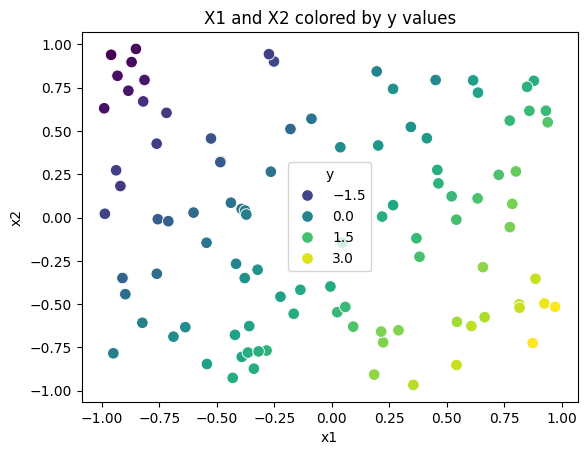

In [26]:
# Visualizing the input features x1 and x2 related to the y 
sns.scatterplot(data=data, x='x1',y="x2", hue='y', palette="viridis", s=70)
plt.title("X1 and X2 colored by y values")
plt.show()

#### Splitting Data 

In [27]:
# Splitting the data into train and test.
def splitting_dataset(X, y, test_size=0.2, seed=42):  
    np.random.seed(seed)
# let's shuffle the data 
    idx=np.random.permutation(len(X))   
# Calculating the split point
    split= int(len(X)*(1-test_size))
    X_train, X_test=X[idx[:split]],X[idx[split:]]
    y_train, y_test=y[idx[:split]],y[idx[split:]] 
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = splitting_dataset(X, y, test_size=0.2)
print(f'Train: {len(X_train)}')
print(f'Test:{len(X_test)}')
# Source: https://numpy.org/doc/2.1/reference/random/generated/numpy.random.Generator.permutation.html

Train: 80
Test:20


#### Initializing parameters 

In [28]:
# In this cell, I am going to initialize weights and bias for 2 layers NN in three different behaviors. 
def initializing_params(mode='random', seed=42):
    np.random.seed(seed)
    b1 = np.zeros((1, 2))
    b2 = np.zeros((1, 1))

    if mode == 'same':
        W1 = np.full((2, 2),0.2)
        W2 = np.full((2, 1), 0.2)
    elif mode == "random":
        W1 = np.random.normal(0, 0.5, (2, 2))
        W2 = np.random.normal(0, 0.5,(2,1))
    elif mode == "large":
        W1 = np.random.normal(0,3.0, (2, 2))
        W2 = np.random.normal(0,3.0, (2, 1))
    else:
        return None
    return {"W1": W1, 'b1': b1, "W2": W2, "b2": b2}
parameters = initializing_params(mode='random', seed=42)
# Source:  Lecture slides from Deep Learning course.  
# For debugging, I used QWEN 3 MAX

#### Forward pass, loss and backpropagation

In [29]:
def forward_pass(X, weights):
    hidden_layer_values=X @ weights['W1'] + weights['b1']
    a_hidden= np.tanh(hidden_layer_values)
# Output layer
    y_predicted= a_hidden @ weights['W2'] +weights['b2']   
# let's save values, I will need them for backpropagation.
    cache = {'z_hidden':hidden_layer_values, 'a_hidden':a_hidden}
    return y_predicted, cache


# loss function for calculating the prediction miatake. 
def loss_mse(y_predicted, actual_y):
    return np.mean((y_predicted - actual_y)**2)


In [30]:
# To know how much each parameter contributed to the final error,  I need backpropagation.
# Then optimizer will use gradients to update the parameters and minimize the error.


def backward_pass(X, actual_y, weights, y_predicted, cache):
    number_rows = X.shape[0]

    prediction_error = 2*(y_predicted - actual_y) / number_rows
    gradient_output_weight = cache['a_hidden'].T @ prediction_error
    gradient_output_bias = np.sum(prediction_error, axis=0, keepdims=True)
    

    error_to_hidden_layer = prediction_error @ weights['W2'].T
    gradient_z = error_to_hidden_layer * (1-cache["a_hidden"]**2)
    
    derivative_tanh=X.T @ gradient_z
    gradient_hidden_layer_weight=np.sum(gradient_z, axis=0, keepdims=True)
    
    return {'W1':derivative_tanh, 'b1':gradient_hidden_layer_weight, "W2":gradient_output_weight, "b2":gradient_output_bias}
# Source: Lecture slides from Deep Learning course.
# For debugging, I used QWEN 3 MAX

#### Optimizer 

In [31]:
# Calculating loss and calculating the gradients then updating the variables with optimizer.
def Optimizer(params, gradiant, learning_rate):
    for name in params:
        params[name]-=learning_rate*gradiant[name]
# Source: https://www.tensorflow.org/guide/basic_training_loops

#### Training loop 

In [32]:
# Creating a training loop function

def training(X_train,y_train, X_test, y_test, learning_rate=0.05, epochs=1500, seed=42, init_mode='random'):
    params = initializing_params(seed=seed, mode=init_mode)
    history = []

    for epoch in range(epochs):        
        y_predicted, cache=forward_pass(X_train, params)
        gradients = backward_pass(X_train, y_train, params, y_predicted, cache)
        Optimizer(params, gradients, learning_rate)

        train_predicted, _ = forward_pass(X_train, params)
        test_predicted, _ = forward_pass(X_test, params)


        history.append({"epoch":epoch,'train_loss':loss_mse(train_predicted, y_train),
                        'test_loss':loss_mse(test_predicted, y_test)})
        
    return params, pd.DataFrame(history)

In [33]:
# Here, I am going to train the model and see the last 5 rows of the history. 
X_train, X_test, y_train, y_test = splitting_dataset(X, y, seed=42)

params, history = training(X_train,y_train,X_test,y_test,learning_rate=0.05,epochs=1500,seed=42,init_mode="random")
history.tail()
# What I can see from the 5 last rows of the history
# The  test loss is a bit higher than the train loss, but the gap is not that big, which mean the model is not overfitting.

,epoch,train_loss,test_loss
1495,1495,0.014273,0.014820
1496,1496,0.014271,0.014819
1497,1497,0.014269,0.014818
1498,1498,0.014267,0.014817
1499,1499,0.014265,0.014817


#### Evaluating

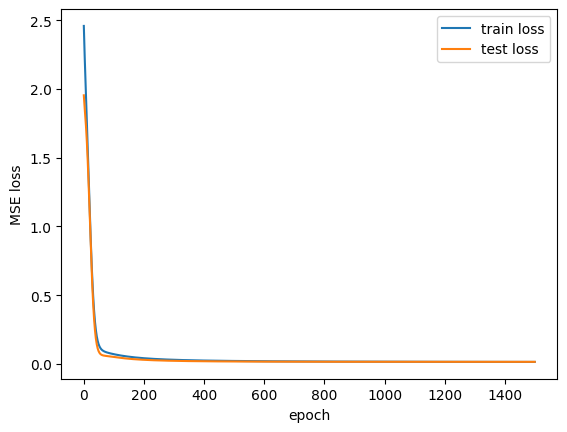

In [34]:
plt.plot(history["epoch"],history["train_loss"], label="train loss")
plt.plot(history["epoch"],history["test_loss"], label="test loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()
# The graph shows the same thing, what I mentioned before, the model has same performance on both train and test.
# The model stoped improving after 200 epochs, so training for 1500 epochs is not necessary. 

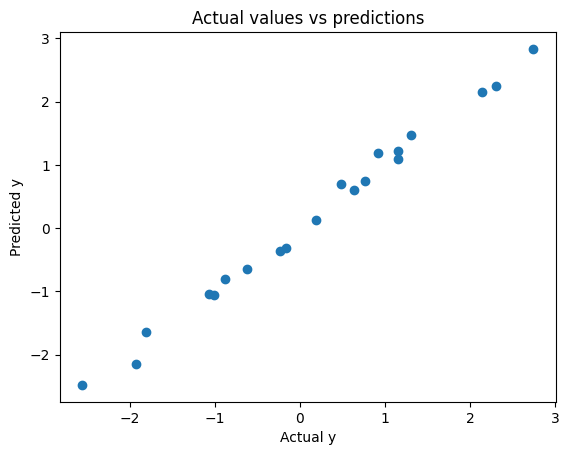

In [35]:
test_predicted, _ = forward_pass(X_test, params)
plt.scatter(y_test, test_predicted)
plt.xlabel('Actual y')
plt.ylabel("Predicted y")
plt.title('Actual values vs predictions')
plt.show()
# Plot also shows that the model learned the pattern in the DS. 

#### Learning rate experiment

In [36]:
# In this cell, let's experiment with different learning rates 
# to see that  how model can be stable with different learning. 
learning_rates = [0.005, 0.02, 0.05, 0.25]
learning_rate_results = []

for learning_rate in learning_rates:
     _, history = training(X_train, y_train, X_test, y_test, learning_rate=learning_rate, epochs=1500, seed=42,init_mode="random")
     learning_rate_results.append({'learning_rate':learning_rate, "last_train_loss":history["train_loss"].iloc[-1],
                                   "last_test_loss":history['test_loss'].iloc[-1]})

pd.DataFrame(learning_rate_results)
# 0.05 gave the best result.

,learning_rate,last_train_loss,last_test_loss
0,0.005,0.052143,0.037273
1,0.020,0.019348,0.016478
2,0.050,0.014265,0.014817
3,0.250,0.019958,0.020421


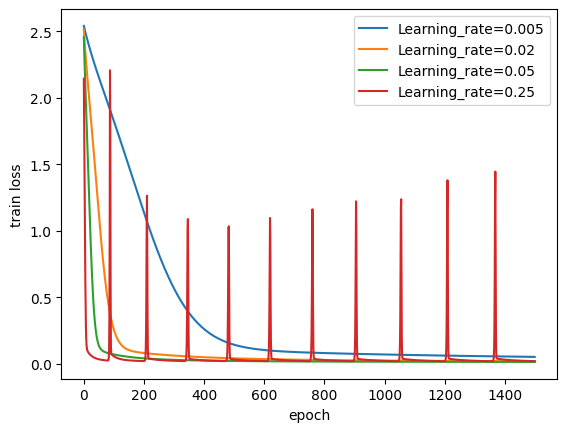

In [37]:
# Viusalizing the train loss for different learning rates.
for learning_rate in learning_rates:
    _, history = training(X_train, y_train, X_test, y_test, learning_rate=learning_rate, epochs=1500, seed=42, init_mode="random")
    plt.plot(history['epoch'], history['train_loss'], label=f"Learning_rate={learning_rate}")

plt.xlabel("epoch")
plt.ylabel("train loss")
plt.legend()
plt.show()
# The graph shows the same thing, 0.05 is the best learning rate compared to the others. 

In [38]:
# Now let's experiment with different behaviors of initializing the weights and bias.
initializing_modes = ['random', 'same', "large"]
init_results = []

for mode in initializing_modes:
    _, history = training(X_train, y_train, X_test, y_test, learning_rate=0.05,epochs=1500, seed=42, init_mode=mode)
    init_results.append({"mode":mode, "last_train_loss":history["train_loss"].iloc[-1],"last_test_loss":history["test_loss"].iloc[-1]})
pd.DataFrame(init_results)

,mode,last_train_loss,last_test_loss
0,random,0.014265,0.014817
1,same,0.015458,0.012781
2,large,0.031933,0.028191


In [39]:
# Finally, let's experiment with different distributions of the DS 
distributions = ['uniform', 'normal', 'wide']
results = []

for dist in distributions:
    X, y = generate_data(size=100, distribution=dist, target="linear", seed=42)
    X_train, X_test, y_train, y_test = splitting_dataset(X, y, seed=42)

    _, history = training(X_train, y_train, X_test, y_test, learning_rate=0.05, epochs=1500, seed=42, init_mode="random")
    results.append({ "distribution": dist,"last_train_loss": history["train_loss"].iloc[-1],"last_test_loss": history["test_loss"].iloc[-1]})

pd.DataFrame(results)
# What I can see from the results, the model has the best performance on the uniform 
# Which make sense, because scaled data between -1 and 1


,distribution,last_train_loss,last_test_loss
0,uniform,0.014265,0.014817
1,normal,0.013323,0.078840
2,wide,9.143552,13.862403


In [40]:
def check_one_gradient(X, y, params, epsilon=0.00001):
    y_predicted, cache = forward_pass(X, params)
    gradients = backward_pass(X, y, params, y_predicted, cache)

    original = params["W1"][0, 0]
    params["W1"][0, 0] = original + epsilon
    loss_plus = loss_mse(forward_pass(X, params)[0], y)

    params["W1"][0, 0] = original - epsilon
    loss_minus = loss_mse(forward_pass(X, params)[0], y)

    params["W1"][0, 0] = original

    numerical_gradient = (loss_plus - loss_minus)/(2*epsilon)
    manual_gradient = gradients["W1"][0, 0]
    return numerical_gradient, manual_gradient

# I changed one weight and checked how the loss changed. Then I compared this numerical gradient with my manual backpropagation gradient.
# If they are close, my derivative logic can be correct.

# For debugging, I used QWEN 3 MAX

In [41]:
X, y = generate_data(size=20, distribution="uniform", target='linear', seed=1)
params = initializing_params(seed=1, mode='random')

check_one_gradient(X, y, params)
# The difference is too small.

(np.float64(-0.10639838274872913), np.float64(-0.10639838274640573))

In [ ]:
# Main source:https://vinitvyas.com/posts/backprop-part-1